## Reinforcement Learning
Reinforcement Learning (RL) is a branch of machine learning that focuses on how agents can learn to make decisions through trial and error to maximize cumulative rewards

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)


In [21]:
num_episodes = 5000
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

### num_episodes: Number of times the agent tries to solve the maze to learn.
### alpha: Learning rate – how fast the agent updates its knowledge.
### gamma: Discount factor – how much future rewards matter.
### epsilon: Exploration rate – chance of taking a random action.
### reward_fire: Penalty for hitting a wall or bad cell.
### reward_goal: Reward for reaching the goal.
### reward_step: Small penalty for each move to encourage shorter paths.
### actions: Possible moves (left, right, up, down).
### Q: Table that stores how good each action is in each maze cell.


In [23]:
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True


def choose_action(state):
    if np.random.random() < epsilon:
        return np.random.randint(len(actions))
    else:
        return np.argmax(Q[state])

In [24]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state = start
    total_rewards = 0
    done = False

    while not done:
        action_index = choose_action(state)
        action = actions[action_index]

        next_state = (state[0] + action[0], state[1] + action[1])

        if not is_valid(next_state):
            reward = reward_fire
            done = True
        elif next_state == goal:
            reward = reward_goal
            done = True
        else:
            reward = reward_step

        old_value = Q[state][action_index]
        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0

        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)

        state = next_state
        total_rewards += reward

    global epsilon
    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards)

In [25]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                    next_state not in visited):

                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path


optimal_path = get_optimal_path(Q, start, goal, actions, maze)

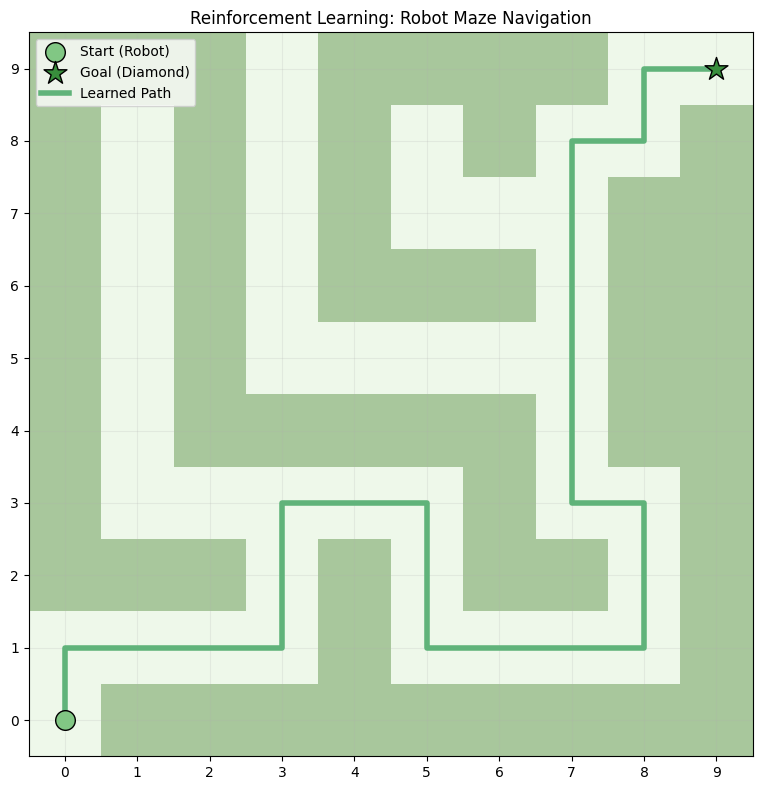

In [26]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_maze_with_path(optimal_path)

In [1]:
!pip install gymnasium numpy


In [8]:
import gymnasium as gym
import numpy as np

# Create environment
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# Initialize Q-table
state_size = env.observation_space.n
action_size = env.action_space.n
Q = np.zeros((state_size, action_size))

# Hyperparameters
learning_rate = 0.8
discount_factor = 0.95
episodes = 2000
max_steps = 100

In [4]:

epsilon = 1.0        # exploration rate
epsilon_decay = 0.001
epsilon_min = 0.01

In [9]:
# Training loop
for episode in range(episodes):
    state, _ = env.reset() # gymnasium reset returns (observation, info)

    for step in range(max_steps):
        # Choose action (explore vs exploit)
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        # gymnasium step returns (observation, reward, terminated, truncated, info)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated # Combine terminated and truncated for the Q-learning loop

        # Q-learning update
        Q[state, action] = Q[state, action] + learning_rate * (
            reward + discount_factor * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state

        if done:
            break

    # Reduce exploration
    epsilon = max(epsilon_min, epsilon - epsilon_decay)

print("Training finished!")
print(Q)

Training finished!
[[0.73509189 0.77378094 0.77378094 0.73509189]
 [0.73509189 0.         0.81450625 0.77378094]
 [0.77378094 0.857375   0.77378094 0.81450625]
 [0.81450625 0.         0.77378056 0.7737568 ]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81450625]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


In [11]:
state, _ = env.reset()
done = False

env.render()
while not done:
    action = np.argmax(Q[state])
    state, reward, done, _, _ = env.step(action)
    env.render()


In [12]:
!pip install torch matplotlib

In [13]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque

env = gym.make("CartPole-v1")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:

# Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_size, 24),
            nn.ReLU(),
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, action_size)
        )

    def forward(self, x):
        return self.fc(x)

In [15]:

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

model = DQN(state_size, action_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

memory = deque(maxlen=2000)

gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
batch_size = 32

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
# Training
for episode in range(300):
    state, _ = env.reset()
    state = torch.FloatTensor(state)
    total_reward = 0

    while True:
        # Choose action
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = torch.argmax(model(state)).item()

        next_state, reward, done, _, _ = env.step(action)
        next_state = torch.FloatTensor(next_state)

        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward

        if done:
            print(f"Episode {episode}, Reward: {total_reward}")
            break

        # Train
        if len(memory) >= batch_size:
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.stack(states)
            actions = torch.tensor(actions)
            rewards = torch.tensor(rewards)
            next_states = torch.stack(next_states)
            dones = torch.tensor(dones, dtype=torch.float)

            q_values = model(states).gather(1, actions.unsqueeze(1)).squeeze()
            next_q = model(next_states).max(1)[0]
            target = rewards + gamma * next_q * (1 - dones)

            loss = loss_fn(q_values, target.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

Episode 0, Reward: 12.0
Episode 1, Reward: 17.0
Episode 2, Reward: 14.0
Episode 3, Reward: 17.0
Episode 4, Reward: 23.0
Episode 5, Reward: 31.0
Episode 6, Reward: 17.0
Episode 7, Reward: 13.0
Episode 8, Reward: 12.0
Episode 9, Reward: 45.0
Episode 10, Reward: 19.0
Episode 11, Reward: 15.0
Episode 12, Reward: 33.0
Episode 13, Reward: 16.0
Episode 14, Reward: 12.0
Episode 15, Reward: 15.0
Episode 16, Reward: 22.0
Episode 17, Reward: 22.0
Episode 18, Reward: 13.0
Episode 19, Reward: 13.0
Episode 20, Reward: 10.0
Episode 21, Reward: 25.0
Episode 22, Reward: 23.0
Episode 23, Reward: 17.0
Episode 24, Reward: 39.0
Episode 25, Reward: 20.0
Episode 26, Reward: 8.0
Episode 27, Reward: 23.0
Episode 28, Reward: 21.0
Episode 29, Reward: 27.0
Episode 30, Reward: 13.0
Episode 31, Reward: 28.0
Episode 32, Reward: 35.0
Episode 33, Reward: 23.0
Episode 34, Reward: 14.0
Episode 35, Reward: 38.0
Episode 36, Reward: 22.0
Episode 37, Reward: 14.0
Episode 38, Reward: 14.0
Episode 39, Reward: 22.0
Episode 40,

In [17]:
torch.save(model.state_dict(), "dqn_cartpole.pth")


In [18]:
model.eval()

DQN(
  (fc): Sequential(
    (0): Linear(in_features=4, out_features=24, bias=True)
    (1): ReLU()
    (2): Linear(in_features=24, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=2, bias=True)
  )
)

In [19]:
state, _ = env.reset()
state = torch.FloatTensor(state)

total_reward = 0
done = False

while not done:
    with torch.no_grad():
        action = torch.argmax(model(state)).item()

    next_state, reward, done, _, _ = env.step(action)
    state = torch.FloatTensor(next_state)

    total_reward += reward

print("Total Test Reward:", total_reward)
env.close()


Total Test Reward: 156.0
